In [1]:
from jax import random
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import HMC, MCMC, MixedHMC, NUTS
import numpy as np
from scipy.stats import bernoulli, multivariate_normal, pearsonr, norm, multivariate_t, t
from scipy.stats import wasserstein_distance
from sklearn import feature_selection, preprocessing,linear_model
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from math import sqrt
from itertools import cycle
from metrics import absolute_covariance, mean_distance, DP_unfairness_WD, DP_unfairness_TV, individual_unfairness, penalisation_function

from projection import evaluate_posterior_per_budget, evaluate_conjugate_posterior, sample_projection_posterior, sample_posterior_with_projection_prior
from methods import fairlasso, evaluate_calders, evaluate_frrm, standardlasso
from generate_data import simulate_logreg, simulate_linreg
from scipy.stats import gaussian_kde

import rpy2
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects import numpy2ri
#numpy2ri.activate()

In [2]:
# utils = importr('utils')
# utils.install_packages('fairml')
Fairml = importr("fairml")
plt.rcParams.update({'font.size': 14})

### Generate data

In [3]:
data = simulate_linreg(n_train=200, n_test=200, sigma=0.2, rho=1.5, p=0.5, d=2)

Dimension of design matrix: (400, 8)


In [4]:
X_train, y_train, S_train = data["train"]
X_test, y_test, S_test = data["test"]

In [5]:
feature_selection.r_regression(X_train,S_train),  feature_selection.r_regression(y_train,S_train)

(array([ 0.0317473 ,  0.10426674, -0.0750482 ,  0.00763231,  0.61454745,
         0.61208476,  0.58536275,  0.62517753]),
 array([-0.5602398]))

In [6]:
np.cov(y_train.flatten(), S_train)[0,1]

-1.219455342908731

### FRRM : Fair regression with ridge penalty

In [7]:
frrm_train, frrm_val = evaluate_frrm( X_train,  y_train, S_train, X_test, y_test, S_test, budget=None, metric="correlation")

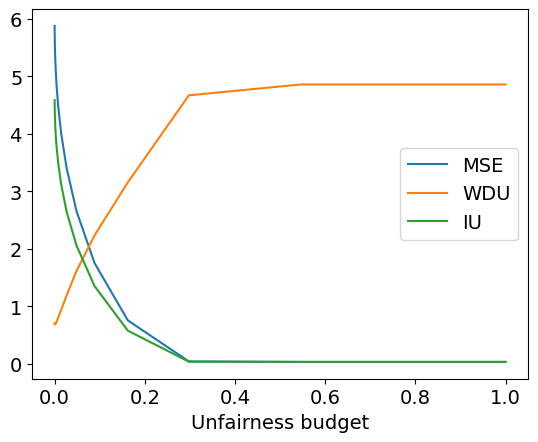

In [8]:
budget=frrm_train["budget"]
for m in ["MSE", "WDU", "IU"]:
    plt.plot(budget, frrm_train[m], label=m)
plt.xlabel("Unfairness budget")
plt.legend()

### LASSO

In [9]:
# alpha_path, coeff_path,_= linear_model.lasso_path(X_train, y_train)
# coeff_path.shape

In [10]:
#alpha_path

In [11]:
alphas  = np.logspace( -2, 1., num=100, endpoint=True, base=10.0)

In [12]:
# for alpha in alphas:
#     lasso = linear_model.Lasso(alpha=alpha, fit_intercept=True, max_iter=50000)
#     lasso.fit(X_train, y_train.reshape(-1,) )
#     print(np.insert(lasso.coef_ , 0, lasso.intercept_))

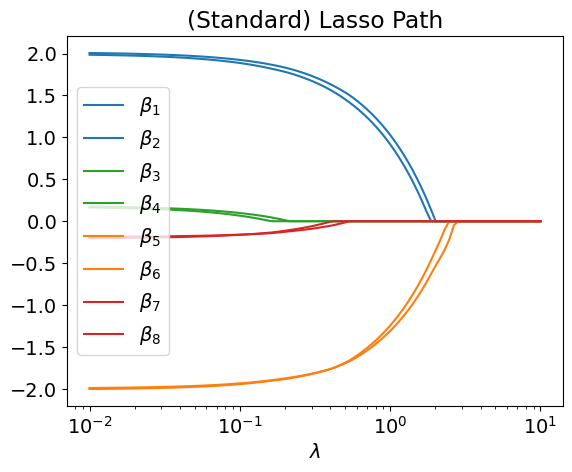

In [13]:
lasso = standardlasso()
lasso_results_train, lasso_results_val = lasso.evaluate(X_train, S_train, y_train, X_test, S_test, y_test, alphas= alphas, #alpha_path,
                                                                 coeff=5.0, metric="correlation")

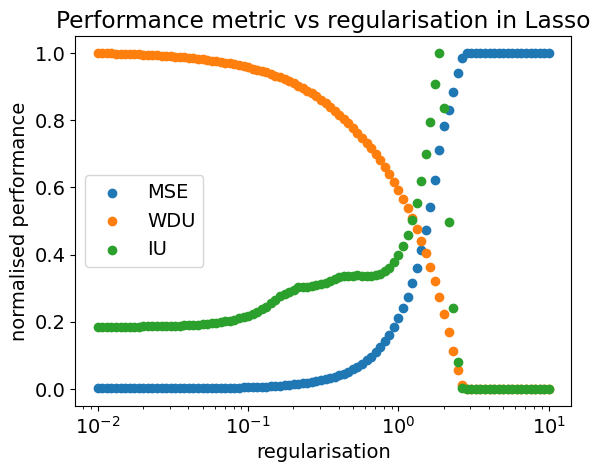

In [14]:
for m in ["MSE", "WDU", "IU"]:
    plt.scatter(lasso_results_train["alphas"], lasso_results_train[m] / max(lasso_results_train[m]), label=m)
#plt.scatter(lasso_results_train["alphas"], lasso_results_train["Correlation"] / max(lasso_results_train["Correlation"]), label="Correlation")
#plt.hlines(y=results_cald_val["mse"][0], xmin=lamda_grid[0], xmax=lamda_grid[-1])
#plt.yscale("log")
plt.title("Performance metric vs regularisation in Lasso")
plt.xlabel("regularisation")
plt.ylabel("normalised performance")
plt.xscale("log")
plt.legend(loc="center left")
plt.savefig("/Users/deborah/PycharmProjects/FairVariableSelection/figures/simulation_lasso.pdf")

### FAIR LASSO

In [15]:
lamdas = np.abs(feature_selection.r_regression(X_train,S_train))
W = np.diag(1.0/lamdas)
X_star= X_train @ W
alphas_fair_lasso, coeff_fair_lasso,_ = linear_model.lasso_path(X_star, y_train)

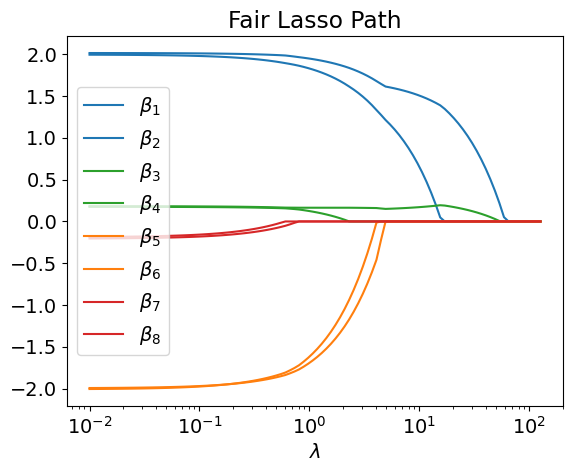

In [16]:
#alphas=np.linspace(0.01,30,200)
alphas_fair_lasso  = np.logspace( -2, 2.1, num=100, endpoint=True, base=10.0)
flasso = fairlasso()
results_train, results_val = flasso.evaluate(X_train, S_train, y_train, X_test, S_test, y_test, alphas=alphas_fair_lasso, metric='correlation', task="reg")

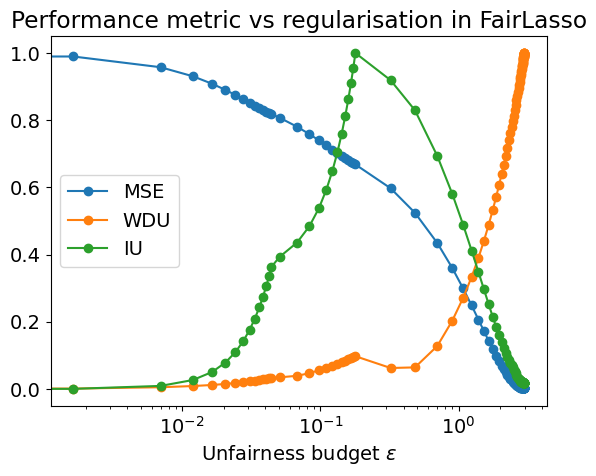

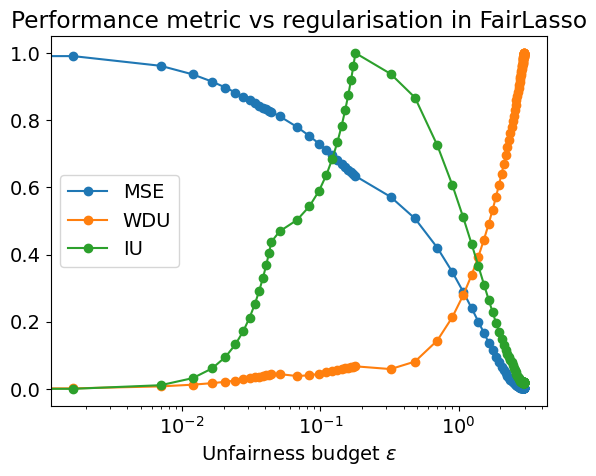

In [17]:
t = ["train", "test"]
for i,results in enumerate([results_train, results_val]):
    fig, ax = plt.subplots()
    for m in ["MSE", "WDU", "IU"]:
        ax.plot(results["budget"], results[m]/ max(results[m]), label=m, marker="o")
    # plt.scatter(results_train["alphas"], results_train["mse"]/ max(results_train["mse"]), label="MSE")
    # plt.scatter(results_train["alphas"], results_train["WDunfair"] /  max(results_train["WDunfair"]), label="DP-WD")
    # plt.scatter(results_train["alphas"], results_train["Indiv"] / max(results_train["Indiv"]), label="Indiv")
    #plt.scatter(results_train["alphas"], results_train["Correlation"], label="Correlation")
    #plt.scatter(results_train["alphas"], results_train["Pen"], label="Penalisation")
    #plt.hlines(y=results_cald_val["mse"][0], xmin=lamda_grid[0], xmax=lamda_grid[-1])
    plt.title("Performance metric vs regularisation in FairLasso")
    plt.xlabel(r"Unfairness budget $\epsilon$")
    #plt.ylabel("normalised performance")
    plt.xscale("log")
    ax.legend()
    plt.savefig(f"/Users/deborah/PycharmProjects/FairVariableSelection/figures/simulation_fairlasso_{t[i]}.pdf")

In [18]:
# max_pen = max(results_train["Pen"])
# plt.scatter(results_train["alphas"], results_train["Pen"]/max_pen, label="Penalisation")
# #plt.hlines(y=results_cald_val["mse"][0], xmin=lamda_grid[0], xmax=lamda_grid[-1])
# plt.xscale("log")
# plt.xlabel(r"$\lambda$")
# plt.ylabel("Penalisation")
# plt.legend()
# plt.savefig("/Users/deborah/PycharmProjects/FairVariableSelection/figures/simulation_comp_lassos_1.pdf")

### Calder's MD

In [19]:
alphas=np.linspace(0.00001,1000,200)
cald_results_train, cald_results_val = evaluate_calders(X_train, S_train, y_train, X_test, S_test, y_test, alphas=alphas)

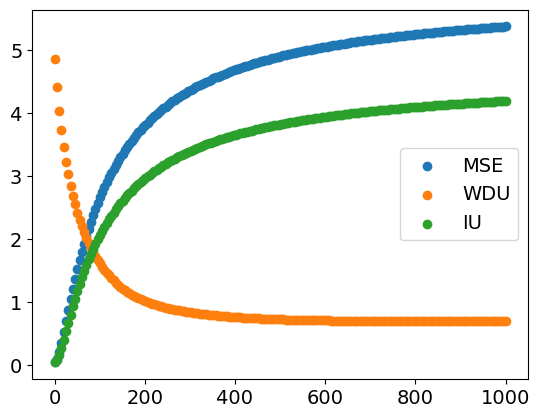

In [20]:
for m in ["MSE", "WDU", "IU"]:
    plt.scatter(cald_results_train["alphas"], cald_results_train[m], label=m)
#plt.scatter(cald_results_train["alphas"], cald_results_train["Correlation"], label="Correlation")
#plt.hlines(y=results_cald_val["mse"][0], xmin=lamda_grid[0], xmax=lamda_grid[-1])
#plt.xscale("log")
plt.legend()

In [21]:
def pareto_plot(m1,m2, fair_lasso_results, lasso_results, frrm_results = None, cald_results = None, fp_results = None, pp_results = None, sp_results = None, save_fig=None, normalise = False, legend=True):

    colors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red']

    if normalise:
        max_1 = max( max(lasso_results[m1]), max(fair_lasso_results[m1]), max(frrm_results[m1]))
        max_2 = max( max(lasso_results[m2]), max(fair_lasso_results[m2]), max(frrm_results[m2]))
    else:
        max_1, max_2 = 1.0,1.0

    fig, ax = plt.subplots()
    ax.plot(  lasso_results[m1]/max_1, lasso_results[m2]/max_2, label="Lasso", marker = "o", color="k")

    ax.plot( fair_lasso_results[m1]/max_1,  fair_lasso_results[m2]/max_2, label="Fair Lasso", marker = "o", color='tab:blue')

    if cald_results is not None:
        ax.plot(  cald_results[m1]/max_1, cald_results[m2]/max_2, label="MD", marker = "o", color="tab:orange")

    if frrm_results is not None:
        ax.plot( frrm_results[m1]/max_1,  frrm_results[m2]/max_2, label="FRRM", marker = "v", color="tab:red")

    if fp_results is not None:
        avg_1 = np.mean(fp_results[m1], axis=1)
        avg_2 = np.mean(fp_results[m2], axis=1)
        ax.plot(  avg_1 / max_1, avg_2 /max_2, label="PP", marker="v", color='tab:brown')

    if pp_results is not None:
        avg_1 = np.mean(pp_results[m1], axis=1)
        avg_2 = np.mean(pp_results[m2], axis=1)
        ax.plot(  avg_1 / max_1, avg_2 /max_2, label="FP", marker = "P", color='tab:green')

    if sp_results is not None:
        avg_1 = np.mean(sp_results[m1], axis=1)
        avg_2 = np.mean(sp_results[m2], axis=1)
        ax.plot(  avg_1 / max_1, avg_2 /max_2, label="SP", marker = "v", color="k")

    #plt.yscale("log")
    plt.xlabel(m1)
    plt.ylabel(m2)
    if legend:
        plt.legend(loc="best")
    if save_fig is not None:
        plt.savefig("/Users/deborah/PycharmProjects/FairVariableSelection/figures/" + save_fig)

In [22]:
# def pareto_plot(m1,m2, fair_lasso_results, lasso_results, frrm_results, cald_results, fp_results = None, pp_results = None, sp_results = None, save_fig=None):
#     max_1 = max( max(lasso_results[m1]), max(fair_lasso_results[m1]), max(frrm_results[m1]), max(cald_results[m1]))
#     max_2 = max( max(lasso_results[m2]), max(fair_lasso_results[m2]), max(frrm_results[m2]), max(cald_results[m2]))
#     fig, ax = plt.subplots()
#     ax.scatter(  lasso_results[m1]/max_1, lasso_results[m2]/max_2, label="Lasso")
#     ax.scatter(  cald_results[m1]/max_1, cald_results[m2]/max_2, label="MD")
#     ax.scatter( frrm_results[m1]/max_1,  frrm_results[m2]/max_2, label="FRRM")
#     ax.scatter( fair_lasso_results[m1]/max_1,  fair_lasso_results[m2]/max_2, label="Fair Lasso")
#
#     if fp_results is not None:
#         avg_1 = np.mean(fp_results[m1], axis=1)
#         avg_2 = np.mean(fp_results[m2], axis=1)
#         ax.scatter(  avg_1 / max_1, avg_2 /max_2, label="PP")
#
#     if pp_results is not None:
#         avg_1 = np.mean(pp_results[m1], axis=1)
#         avg_2 = np.mean(pp_results[m2], axis=1)
#         ax.scatter(  avg_1 / max_1, avg_2 /max_2, label="PPP")
#
#     if pp_results is not None:
#         avg_1 = np.mean(sp_results[m1], axis=1)
#         avg_2 = np.mean(sp_results[m2], axis=1)
#         ax.scatter(  avg_1 / max_1, avg_2 /max_2, label="SP")
#
#     #plt.yscale("log")
#     plt.xlabel(m1)
#     plt.ylabel(m2)
#     plt.legend()
#     if save_fig is not None:
#         plt.savefig("/Users/deborah/PycharmProjects/FairVariableSelection/figures/" + save_fig)


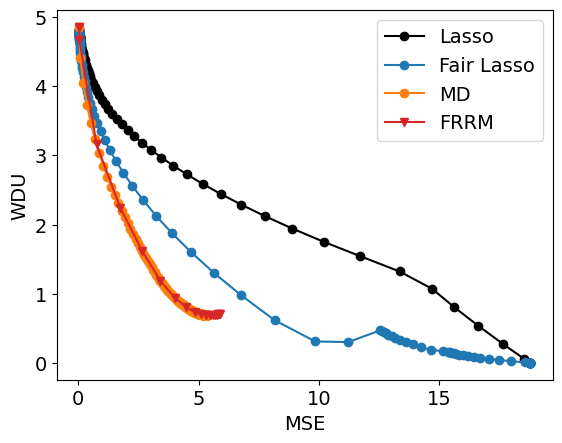

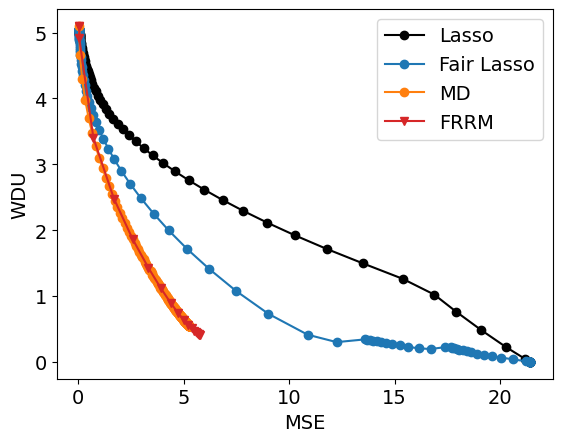

In [23]:
m2,m1 = "WDU", "MSE"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, cald_results_train, save_fig="regression_comp_train_1")
pareto_plot(m1,m2, results_val, lasso_results_val, frrm_val, cald_results_val, save_fig="regression_comp_test_1")

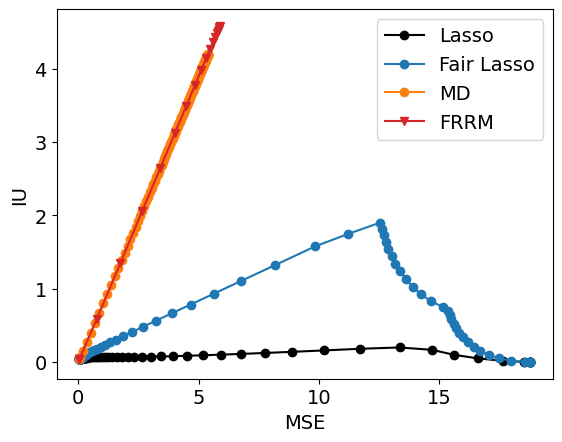

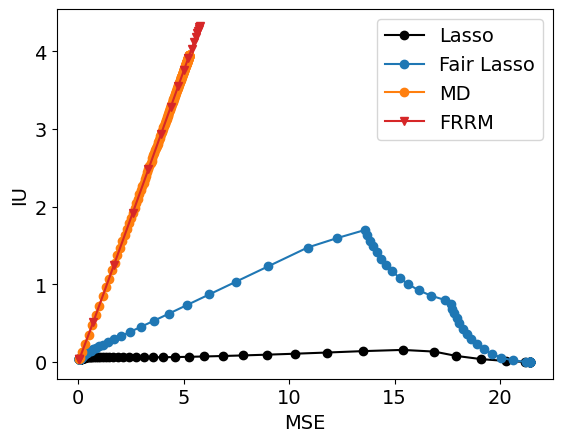

In [24]:
m2,m1 = "IU", "MSE"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, cald_results_train, save_fig="regression_comp_train_2")
pareto_plot(m1,m2, results_val, lasso_results_val, frrm_val, cald_results_val, save_fig="regression_comp_test_2")

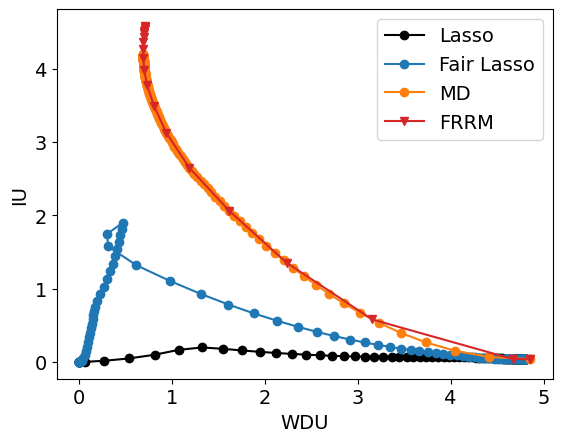

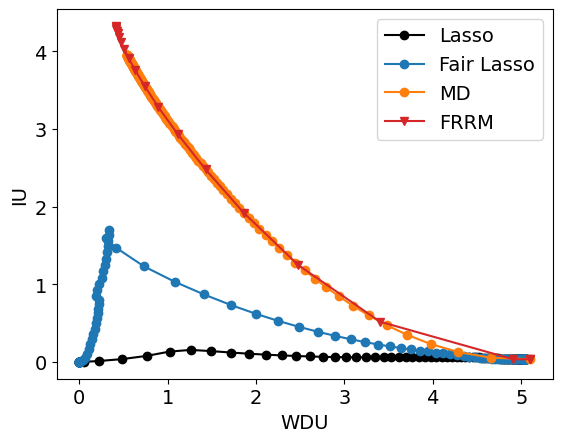

In [25]:
m1,m2 = "WDU", "IU"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, cald_results_train, save_fig="regression_comp_train_3")
pareto_plot(m1,m2, results_val, lasso_results_val, frrm_val, cald_results_val, save_fig="regression_comp_test_3")

### Projected posterior and conjugate posterior

In [26]:
a, b = 1, 1 # hyperparameter of gamma prior
beta_var = 1.0
radius  = np.logspace(-2.8, 1.0, num=50, endpoint=True, base=10.0)
projection_post, conjugate_post = sample_projection_posterior(X_train, y_train, S_train, a=a, b=b, beta_var=beta_var, radius=radius, intercept=True, num_samples = 2000)

In [27]:
fp_results_train, fp_results_test = evaluate_posterior_per_budget(projection_post, X_train, S_train, y_train, X_test, S_test, y_test, sample_from_pp = True)
cp_results_train, cp_results_test = evaluate_conjugate_posterior(conjugate_post, X_train, S_train, y_train, X_test, S_test, y_test, weights=projection_post["weights"], sample_from_pp = False)

In [28]:
projection_post["samples"].shape

(50, 2000, 9)

In [29]:
# check posterior match for big alphas
projection_post["samples"][-1,0,:], conjugate_post["samples"][0,:]

(array([ 0.02840028,  1.99544267,  1.96143639,  0.17883156,  0.16653866,
        -2.04578645, -1.98985339, -0.1559525 , -0.21992287]),
 array([ 0.02840028,  1.99544267,  1.96143639,  0.17883156,  0.16653866,
        -2.04578645, -1.98985339, -0.1559525 , -0.21992287]))

In [30]:
np.mean(conjugate_post["samples var"]),

(0.17220661583356092,)

### Projected prior posterior and sparse posterior

In [31]:
proj_prior = sample_posterior_with_projection_prior(X_train, y_train, S_train, a=a, b=b, beta_var=beta_var, radius=radius, intercept=True, num_samples = 2000, task = "reg",
                                                    metric = "correlation")

sample: 100%|██████████| 3000/3000 [00:00<00:00, 3386.89it/s, 7 steps of size 5.02e-01. acc. prob=0.91]


In [32]:
radius  = np.logspace(-2, 2, num=50, endpoint=True, base=10.0)
sparse_prior = sample_posterior_with_projection_prior(X_train, y_train, S_train, a=a, b=b, beta_var=beta_var, radius=radius, intercept=True, num_samples = 1000, task = "reg",
                                                    metric = None)

sample: 100%|██████████| 2000/2000 [00:01<00:00, 1728.39it/s, 7 steps of size 5.02e-01. acc. prob=0.91]


In [33]:
pp_results_train,pp_results_test = evaluate_posterior_per_budget(proj_prior, X_train, S_train, y_train, X_test, S_test, y_test, sample_from_pp = False)
sp_results_train,sp_results_test = evaluate_posterior_per_budget(sparse_prior, X_train, S_train, y_train, X_test, S_test, y_test, sample_from_pp = False)

In [34]:
weights = np.abs(feature_selection.r_regression(X_train,S_train))
pen_truth = penalisation_function(data["beta"], weights)

In [35]:
def posterior_risk_plot(fp_results, cp_results, savefig = None):

    colors = ["C0", "C1", "C2"]

    plt.figure(figsize=(8, 5))

    for i,m in enumerate(["MSE","WDU",  "IU"]):

        lower = np.percentile(fp_results[m], 2.5, axis=1)
        upper = np.percentile(fp_results[m], 97.5, axis=1)
        median = np.percentile(fp_results[m], 50, axis=1)
        avg = np.mean(fp_results[m], axis=1)

        cp_mean_value = max( np.max(fp_results[m]), np.max(cp_results[m]))
        #cp_mean_value = 1.0
        #cp_mean_value = cp_results_train["pmean"][i]

        plt.fill_between(
            fp_results["budget"],
            lower / cp_mean_value,
            upper / cp_mean_value,
            alpha=0.3,
            color=colors[i]
        )

        plt.plot(fp_results["budget"], avg / cp_mean_value, label=m, linewidth=2, color=colors[i])

        lower = np.percentile(cp_results[m], 2.5)
        upper = np.percentile(cp_results[m], 97.5)
        plt.fill_between(
            fp_results["budget"],
            lower  / cp_mean_value * np.ones(len(fp_results["budget"])),
            upper / cp_mean_value * np.ones(len(fp_results["budget"])),
            alpha=0.2,
            color=colors[i]
        )
        plt.hlines(y=np.mean(cp_results[m]) / cp_mean_value, xmin=min(fp_results["budget"]), xmax=max(fp_results["budget"]), linestyles="dotted", color=colors[i])

    plt.xlabel(r"Unfairness budget $\epsilon$")
    #plt.ylabel("Metric")
    plt.xscale("log")
    plt.legend()
    if savefig is not None:
        plt.savefig("/Users/deborah/PycharmProjects/FairVariableSelection/figures/" + savefig)

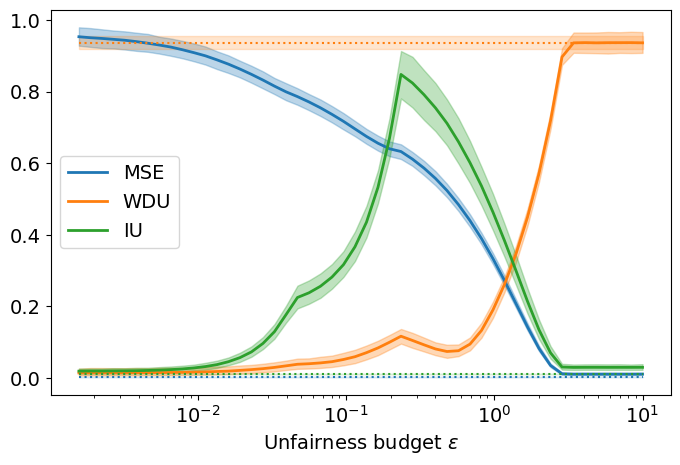

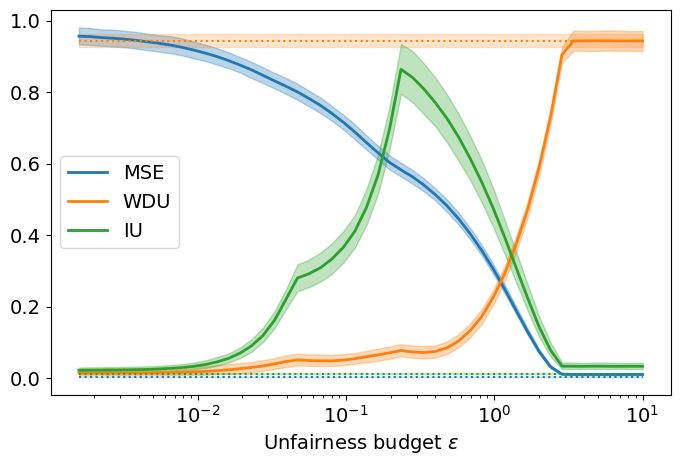

In [36]:
posterior_risk_plot(fp_results_train, cp_results_train, savefig = "regression_pp_train")
posterior_risk_plot(fp_results_test, cp_results_test, savefig = "regression_pp_test")

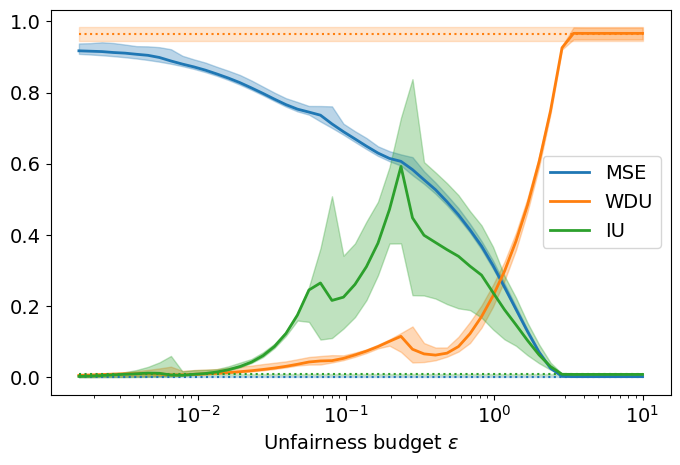

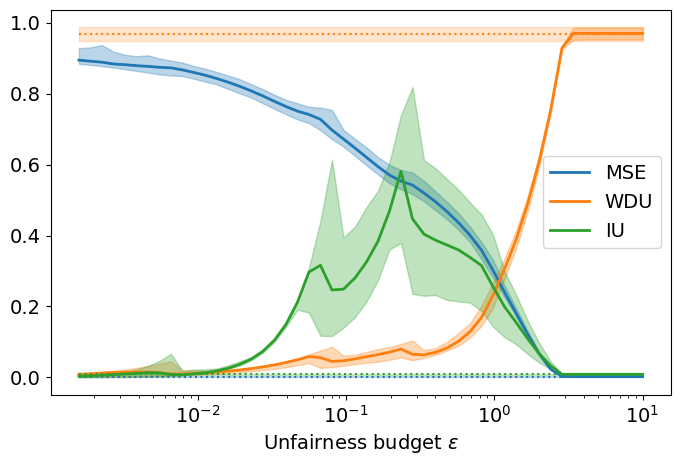

In [37]:
posterior_risk_plot(pp_results_train, cp_results_train, savefig = "regression_ppp_train")
posterior_risk_plot(pp_results_test, cp_results_test, savefig = "regression_ppp_test")

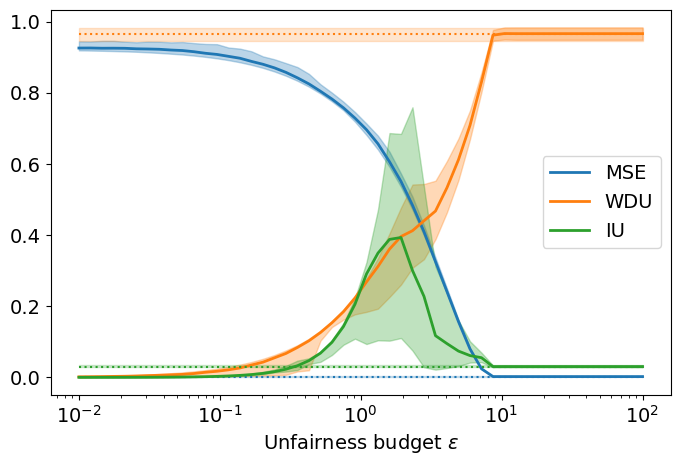

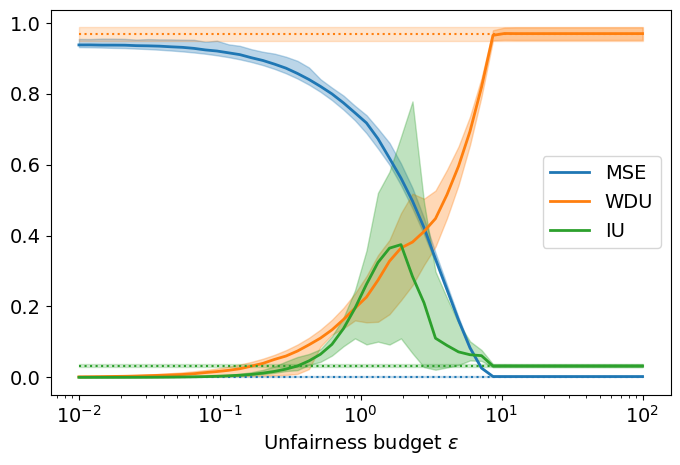

In [38]:
posterior_risk_plot(sp_results_train, cp_results_train, savefig = "regression_sp_train")
posterior_risk_plot(sp_results_test, cp_results_test, savefig = "regression_sp_test")

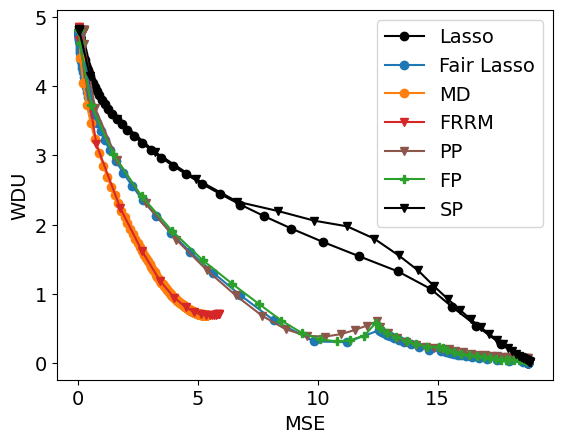

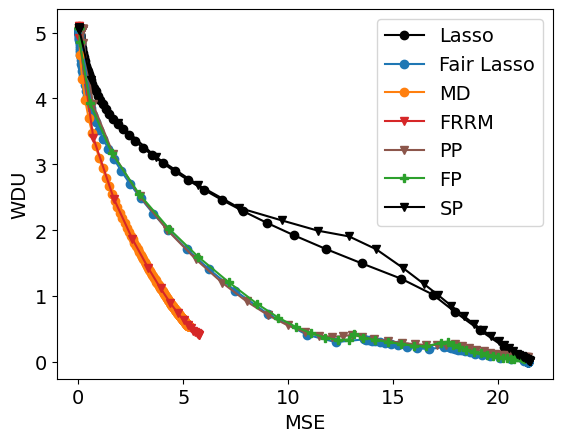

In [39]:
m2,m1 = "WDU", "MSE"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, cald_results_train, fp_results=fp_results_train, pp_results=pp_results_train, sp_results=sp_results_train, save_fig="regression_comp_all_train_1")
pareto_plot(m1,m2, results_val, lasso_results_val, frrm_val, cald_results_val, fp_results=fp_results_test, pp_results=pp_results_test, sp_results=sp_results_test, save_fig="regression_comp_all_test_1")

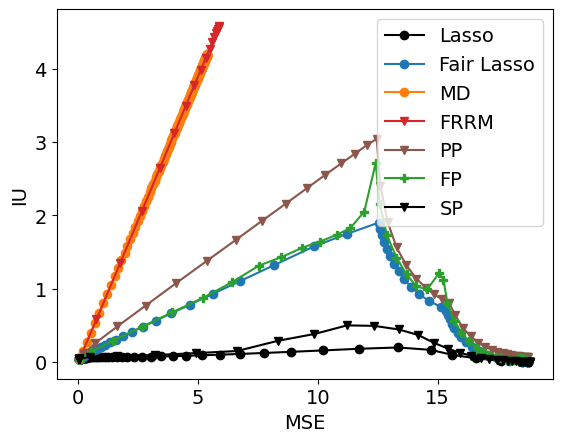

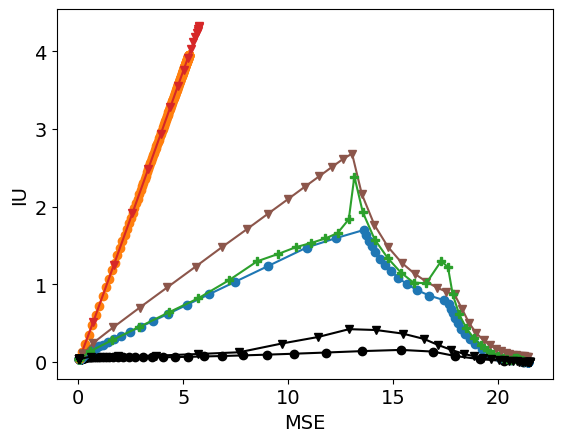

In [40]:
m2,m1 = "IU", "MSE"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, cald_results_train, fp_results=fp_results_train, pp_results=pp_results_train,  sp_results=sp_results_train, save_fig="regression_comp_all_train_2")
pareto_plot(m1,m2, results_val, lasso_results_val, frrm_val, cald_results_val, fp_results=fp_results_test, pp_results=pp_results_test,  sp_results=sp_results_test, save_fig="regression_comp_all_test_2", legend=False)

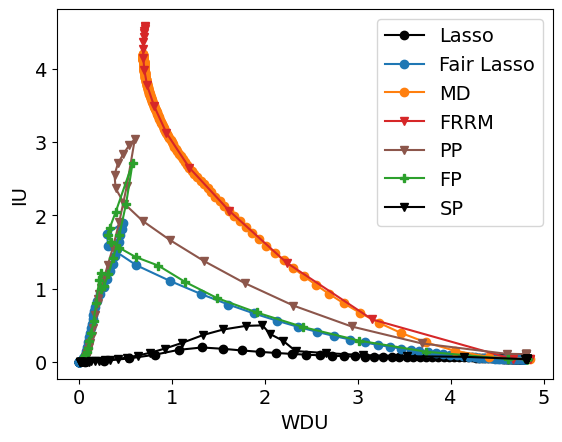

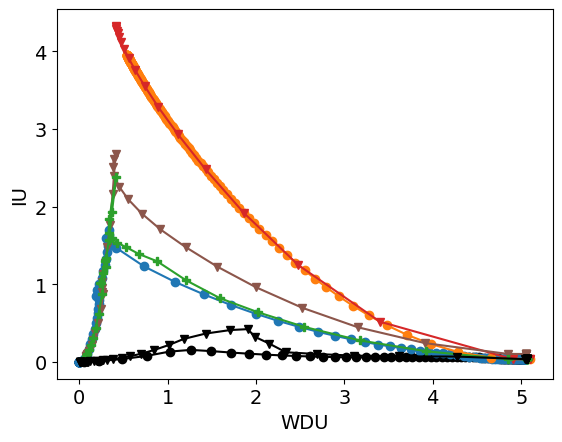

In [41]:
m1,m2 = "WDU", "IU"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, cald_results_train, fp_results=fp_results_train, pp_results=pp_results_train,  sp_results=sp_results_train,  save_fig="regression_comp_all_train_3")
pareto_plot(m1,m2, results_val, lasso_results_val, frrm_val, cald_results_val, fp_results=fp_results_test, pp_results=pp_results_test,  sp_results=sp_results_test, save_fig="regression_comp_all_test_3", legend=False)

Budget :  0.16768329368110074


/Users/deborah/miniconda3/envs/fairness/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/Users/deborah/miniconda3/envs/fairness/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


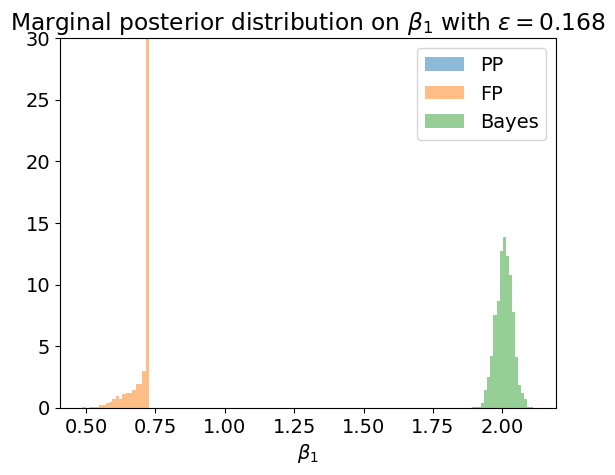

In [42]:
# Compare posterior : feature independent of S
idx = 15
j = 1 # feature
print("Budget : ", radius[idx])
plt.hist(projection_post["samples"][idx,:,j], alpha=0.5, label="PP", density=True, bins=20)
plt.hist(proj_prior["samples"][idx,:,j], alpha=0.5, label="FP", density=True, bins=20)
plt.hist(conjugate_post["samples"][:,j], alpha=0.5, label="Bayes", density=True, bins=20)
#plt.hist(sparse_prior["samples"][idx,:,j], alpha=0.5, label="SP", density=True, bins=20)
plt.legend()
plt.xlabel(rf"$\beta_{j}$")
plt.ylim(0,30)
plt.title(rf"Marginal posterior distribution on $\beta_{j}$ with $\epsilon={radius[idx]:.3f}$")
plt.savefig(f"/Users/deborah/PycharmProjects/FairVariableSelection/figures/regression_post_dist_f{j}_budget_{radius[idx]:.3f}.pdf")

In [43]:
np.mean(np.sqrt(projection_post["samples var"]))

0.41444705102221713

In [44]:
np.mean(np.sqrt(proj_prior["samples var"]), axis=1)

array([4.31271051, 4.31250218, 4.30462061, 4.30199311, 4.29656944,
       4.28863727, 4.28181875, 4.26371221, 4.24015039, 4.21520329,
       4.21244172, 4.1939754 , 4.14974788, 4.12935395, 4.09420677,
       4.06580477, 4.02454264, 3.98476342, 3.94439001, 3.92348985,
       3.88810169, 3.86412218, 3.79607347, 3.73314947, 3.67772446,
       3.63188529, 3.57035012, 3.52755584, 3.50936185, 3.42119172,
       3.33569883, 3.26343757, 3.14792515, 3.02143509, 2.88370182,
       2.72493927, 2.51801404, 2.25600031, 1.96530962, 1.62254137,
       1.21567838, 0.76698775, 0.37868358, 0.35602997, 0.35595353,
       0.35595353, 0.35595353, 0.35595353, 0.35595353, 0.35595353])

Budget :  1.0985411419875584


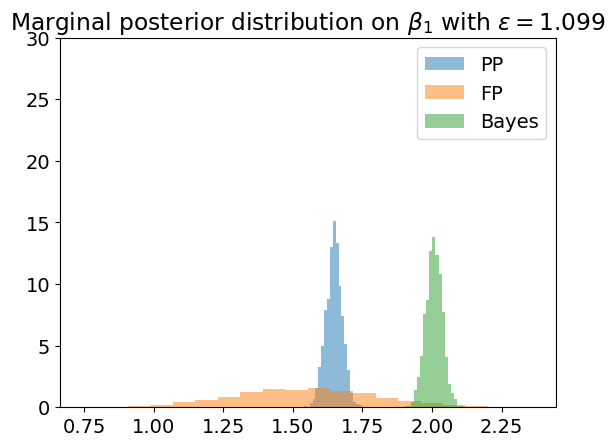

In [45]:
# Compare posterior : feature independent of S
idx = 25
j = 1 # feature
print("Budget : ", radius[idx])
plt.hist(projection_post["samples"][idx,:,j], alpha=0.5, label="PP", density=True, bins=20)
plt.hist(proj_prior["samples"][idx,:,j], alpha=0.5, label="FP", density=True, bins=20)
plt.hist(conjugate_post["samples"][:,j], alpha=0.5, label="Bayes", density=True, bins=20)
plt.legend()
plt.ylim(0,30)
plt.title(rf"Marginal posterior distribution on $\beta_{j}$ with $\epsilon={radius[idx]:.3f}$")
plt.savefig(f"/Users/deborah/PycharmProjects/FairVariableSelection/figures/regression_post_dist_f{j}_budget_{radius[idx]:.3f}.pdf")

Budget :  1.0985411419875584


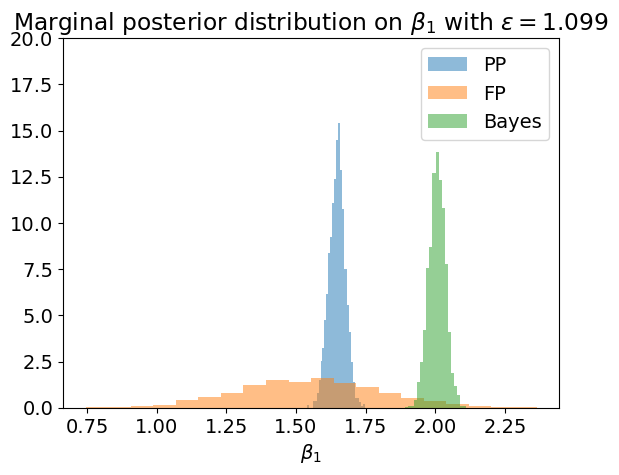

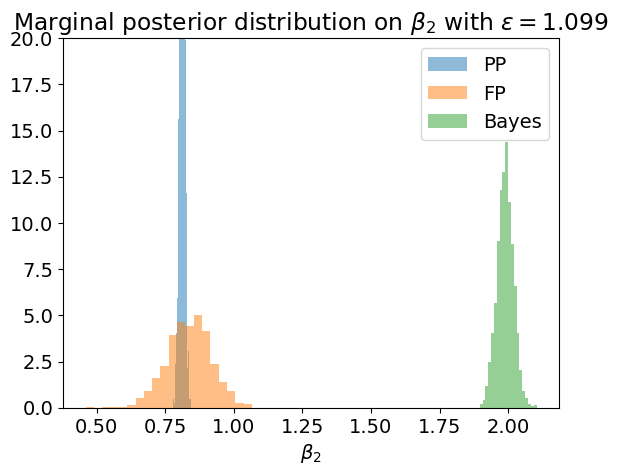

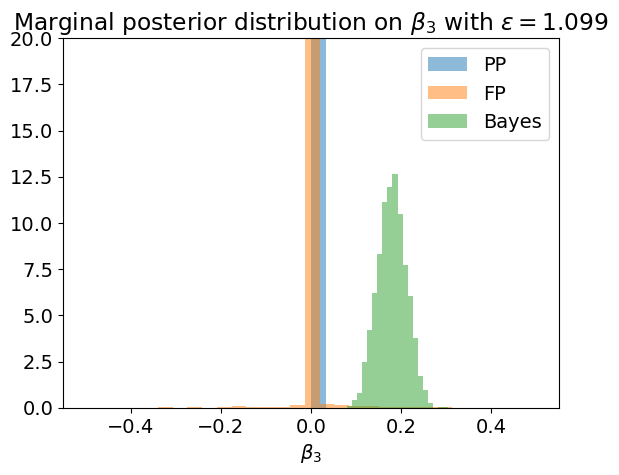

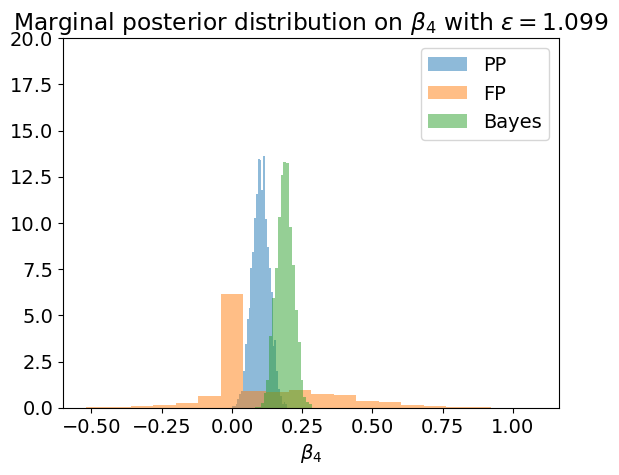

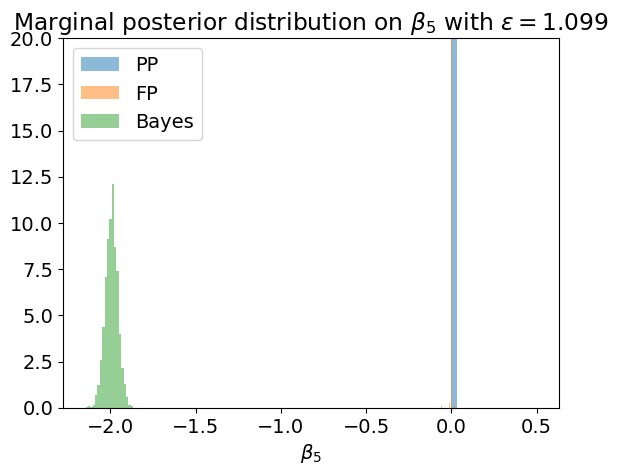

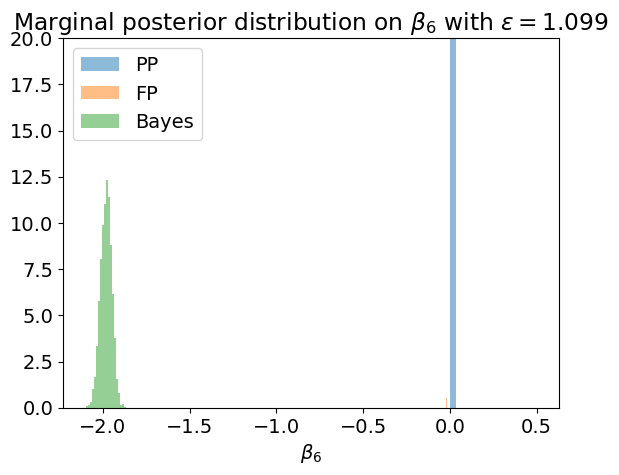

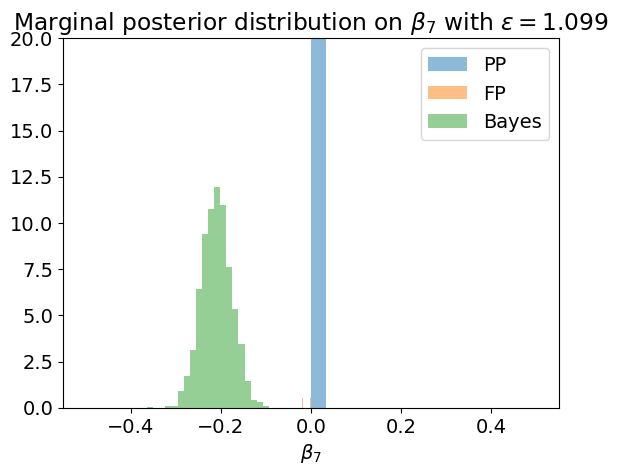

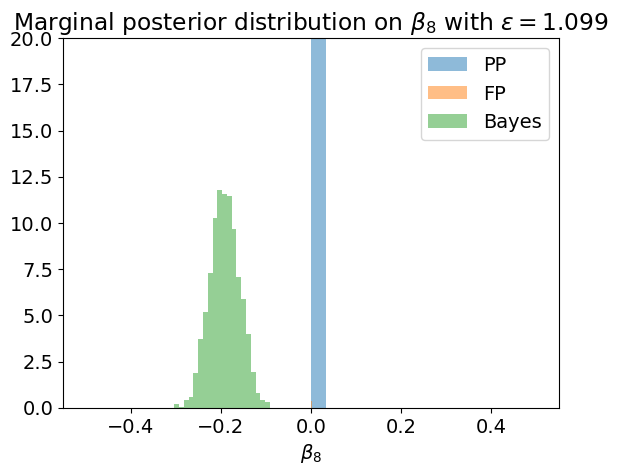

In [46]:
# Compare marginal posterior
idx = 25 # budget
j = 5 # feature
print("Budget : ", radius[idx])
for j in range(1, X_train.shape[1]+1):
    fig, ax = plt.subplots()
    ax.hist(projection_post["samples"][idx,:,j], alpha=0.5, label="PP", density=True, bins=30)
    ax.hist(proj_prior["samples"][idx,:,j], alpha=0.5, label="FP", density=True, bins=20)
    ax.hist(conjugate_post["samples"][:,j], alpha=0.5, label="Bayes", density=True, bins=20)
    plt.legend()
    plt.ylim(0,20)
    plt.xlabel(rf"$\beta_{j}$")
    plt.title(rf"Marginal posterior distribution on $\beta_{j}$ with $\epsilon={radius[idx]:.3f}$")
    plt.savefig(f"/Users/deborah/PycharmProjects/FairVariableSelection/figures/regression_post_dist_f{j}_budget_{radius[idx]:.3f}.pdf")

Budget :  2.811768697974228


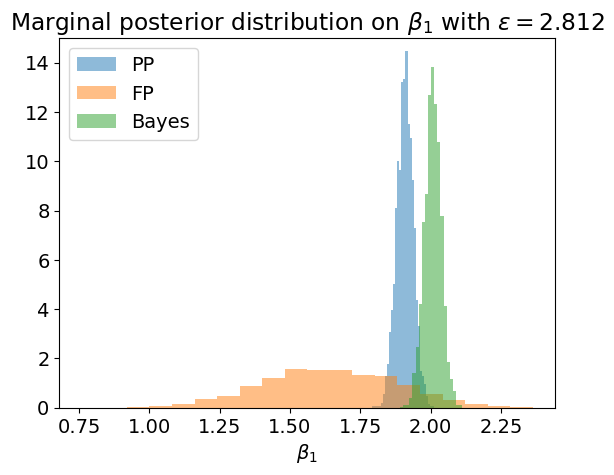

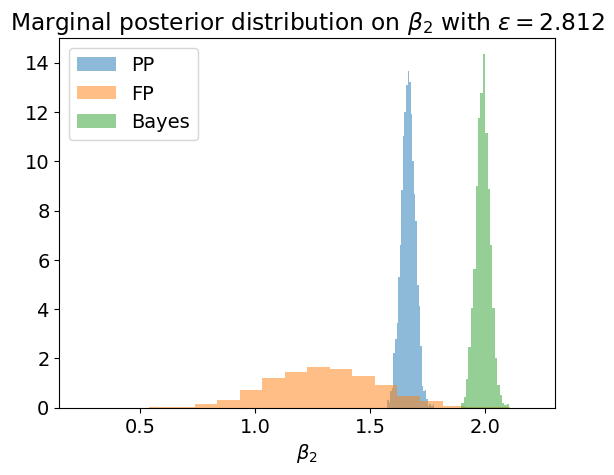

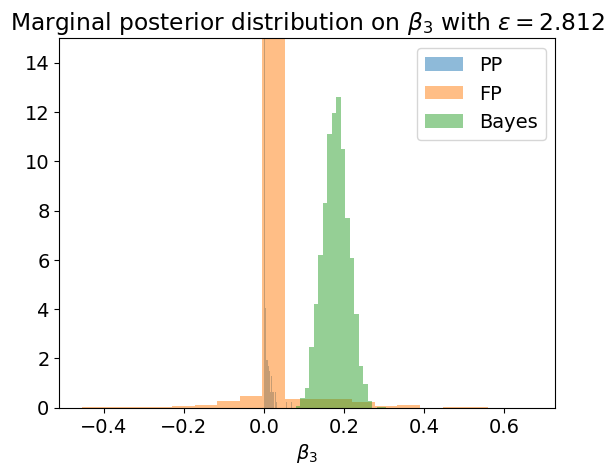

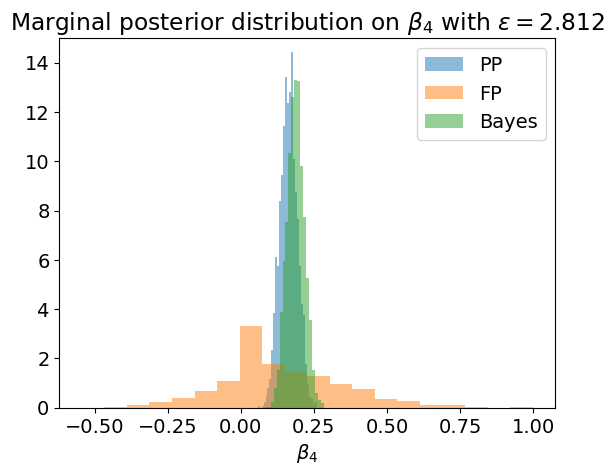

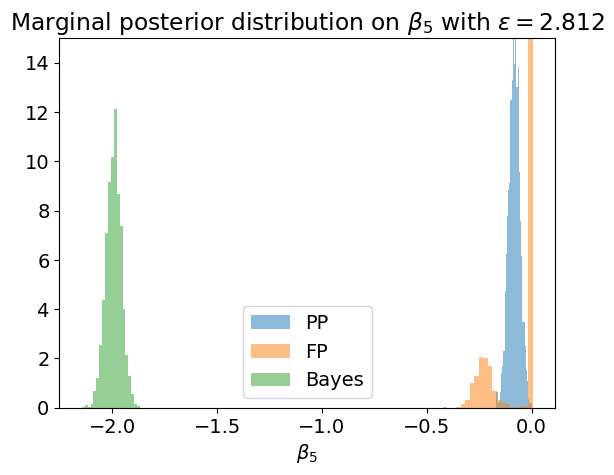

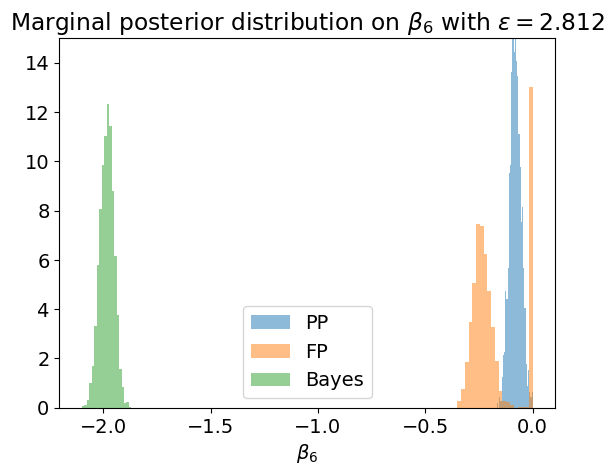

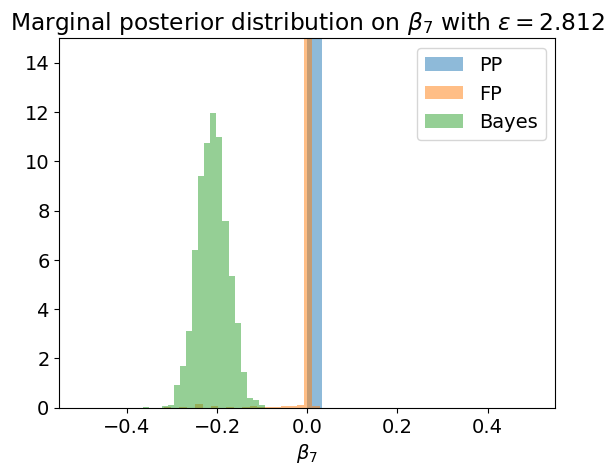

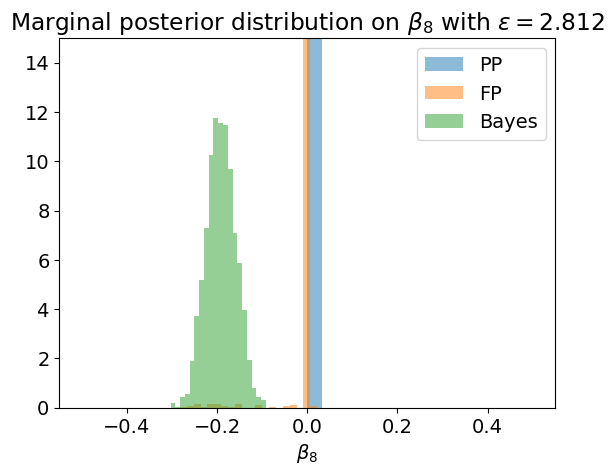

In [54]:
# Compare marginal posterior
idx = 30 # budget
j = 5 # feature
print("Budget : ", radius[idx])
for j in range(1, X_train.shape[1]+1):
    fig, ax = plt.subplots()
    ax.hist(projection_post["samples"][idx,:,j], alpha=0.5, label="PP", density=True, bins=30)
    ax.hist(proj_prior["samples"][idx,:,j], alpha=0.5, label="FP", density=True, bins=20)
    ax.hist(conjugate_post["samples"][:,j], alpha=0.5, label="Bayes", density=True, bins=20)
    plt.legend(loc="best")
    plt.xlabel(rf"$\beta_{j}$")
    plt.ylim(0,15)
    plt.title(rf"Marginal posterior distribution on $\beta_{j}$ with $\epsilon={radius[idx]:.3f}$")
    plt.savefig(f"/Users/deborah/PycharmProjects/FairVariableSelection/figures/regression_post_dist_f{j}_budget_{radius[idx]:.3f}.pdf")

Budget :  1.0985411419875584


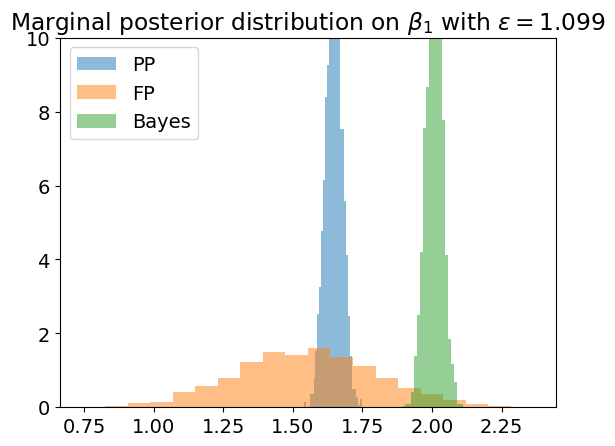

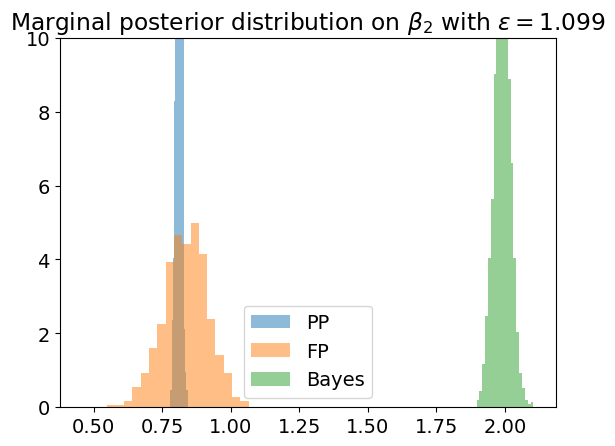

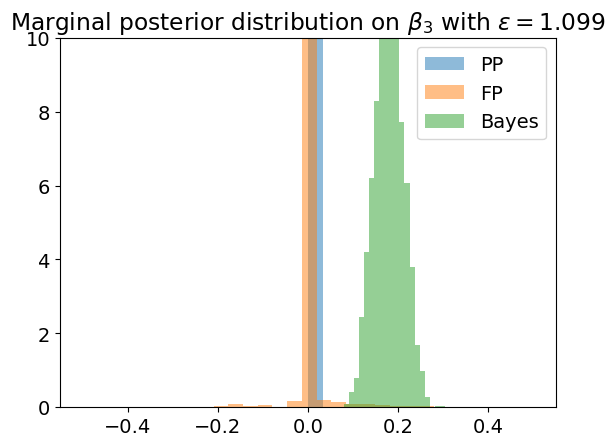

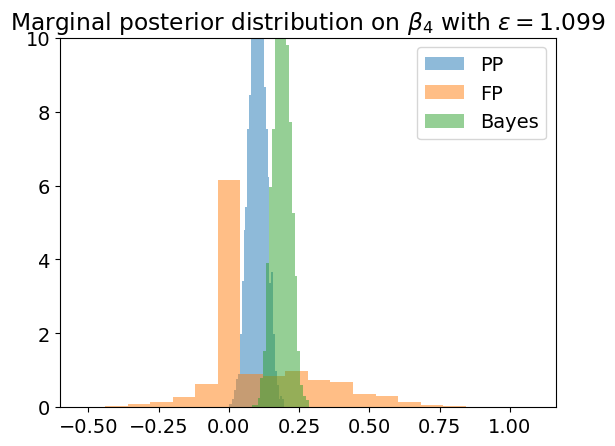

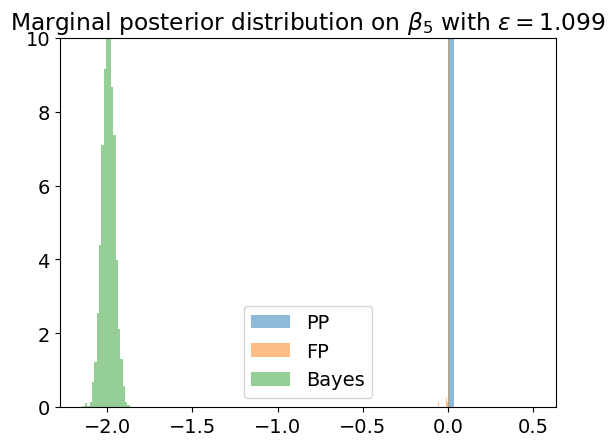

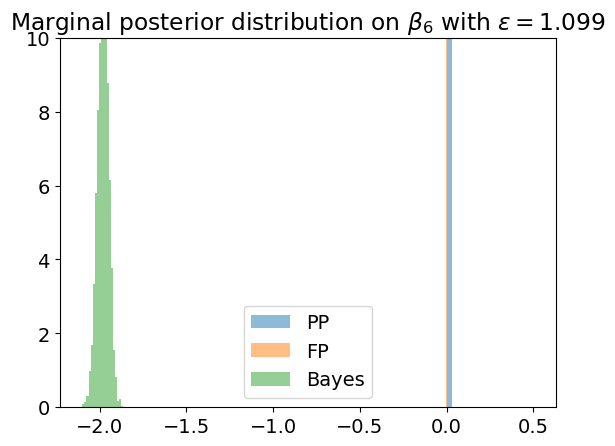

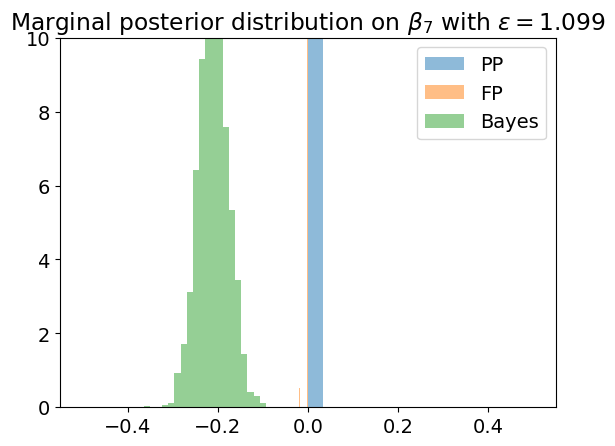

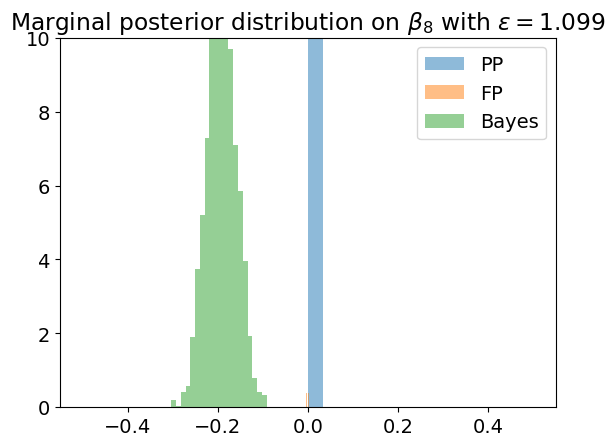

In [48]:
# Compare marginal posterior
idx = 25 # budget
j = 5 # feature
print("Budget : ", radius[idx])
for j in range(1, X_train.shape[1]+1):
    fig, ax = plt.subplots()
    ax.hist(projection_post["samples"][idx,:,j], alpha=0.5, label="PP", density=True, bins=30)
    ax.hist(proj_prior["samples"][idx,:,j], alpha=0.5, label="FP", density=True, bins=20)
    ax.hist(conjugate_post["samples"][:,j], alpha=0.5, label="Bayes", density=True, bins=20)
    plt.legend()
    plt.ylim(0,10)
    plt.title(rf"Marginal posterior distribution on $\beta_{j}$ with $\epsilon={radius[idx]:.3f}$")
    plt.savefig(f"/Users/deborah/PycharmProjects/FairVariableSelection/figures/regression_post_dist_f{j}_budget_{radius[idx]:.3f}.pdf")

In [49]:
# plot posterior risk distribution

def get_hdr_levels(Z, masses):

    z = Z.ravel()

    z_sorted = np.sort(z)[::-1]

    cumsum = np.cumsum(z_sorted)

    cumsum /= cumsum[-1]

    levels = []

    for m in masses:

        idx = np.searchsorted(cumsum, m)

        levels.append(z_sorted[idx])

    levels = sorted(set(levels))

    return levels

def posterior_risk_2D_plot(results, m1, m2, idx1, idx2, idx3, savefig = None):

    # Grid
    x_grid = np.linspace(0, 1, 200)
    y_grid = np.linspace(0, 1, 200)

    #max_1 = max( max(results[m1][idx1]), max(results[m1][idx2]), max(results[m1][idx3]) )
    #max_2 = max( max(results[m2][idx1]), max(results[m2][idx2]), max(results[m2][idx3]) )
    max_1, max_2 = 1.0, 1.0

    metrics1 = [pp_results_train[m1][idx1] / max_1, pp_results_train[m1][idx2] / max_1, pp_results_train[m1][idx3] / max_1]
    metrics2 = [pp_results_train[m2][idx1] / max_2, pp_results_train[m2][idx2] / max_2, pp_results_train[m2][idx3] / max_2]

    colors = ["tab:blue", "tab:orange", "tab:red"]
    labels = [results["budget"][idx1], results["budget"][idx2], results["budget"][idx3]]

    plt.figure()


    X, Y = np.meshgrid(x_grid, y_grid)
    positions = np.vstack([X.ravel(), Y.ravel()])


    for i in range(len(metrics1)):

        values = np.vstack([metrics1[i],metrics2[i]])
        kde = gaussian_kde(values)
        Z = kde(positions).reshape(X.shape)

        levels = get_hdr_levels(Z, masses=[0.50, 0.70, 0.9])
        #print(levels)

        plt.contour(X,Y,Z,levels=sorted(levels), colors=colors[i])

        plt.scatter(metrics1[i],metrics2[i],alpha=0.4,s=7, color=colors[i], label=rf"$\epsilon$={labels[i]:.2f}")

    plt.legend()
    plt.xlabel(m1)
    plt.ylabel(m2)
    plt.title("Fair Posterior risk")

    #plt.savefig("/Users/deborah/PycharmProjects/FairVariableSelection/figures/community_fairpost2_dist3.pdf")

    if savefig is not None:
        plt.savefig("/Users/deborah/PycharmProjects/FairVariableSelection/figures/" + savefig)

    plt.show()

/var/folders/3v/7y8crp4n3fd1qpslr_sxl7c00000gn/T/ipykernel_9212/3201552591.py:11: RuntimeWarning: invalid value encountered in divide
  cumsum /= cumsum[-1]


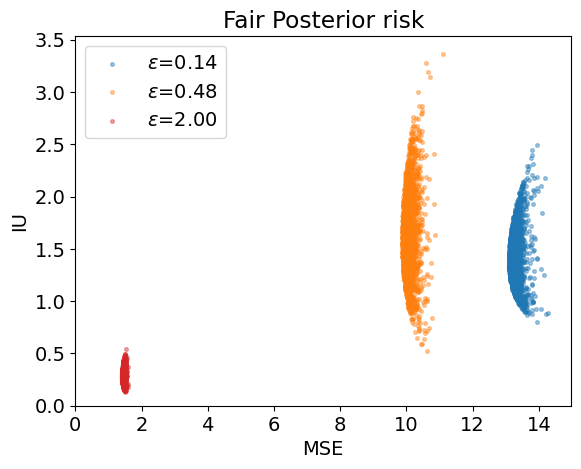

/var/folders/3v/7y8crp4n3fd1qpslr_sxl7c00000gn/T/ipykernel_9212/3201552591.py:11: RuntimeWarning: invalid value encountered in divide
  cumsum /= cumsum[-1]


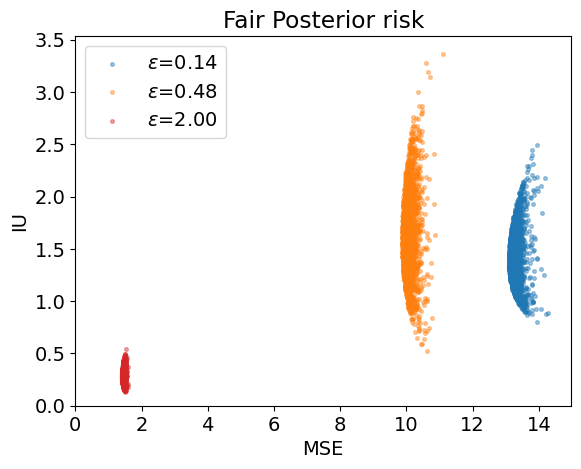

In [50]:
posterior_risk_2D_plot(fp_results_train, m1 = "MSE", m2="IU", idx1=25, idx2=32, idx3=-10, savefig="regression_pp_risk_mse_iu_train.pdf")
posterior_risk_2D_plot(fp_results_test, m1 = "MSE", m2="IU", idx1=25, idx2=32, idx3=-10, savefig="regression_pp_risk_mse_iu_test.pdf")

/var/folders/3v/7y8crp4n3fd1qpslr_sxl7c00000gn/T/ipykernel_9212/3201552591.py:11: RuntimeWarning: invalid value encountered in divide
  cumsum /= cumsum[-1]


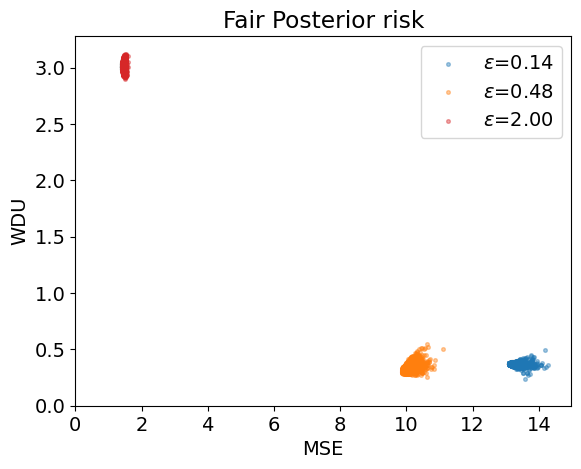

/var/folders/3v/7y8crp4n3fd1qpslr_sxl7c00000gn/T/ipykernel_9212/3201552591.py:11: RuntimeWarning: invalid value encountered in divide
  cumsum /= cumsum[-1]


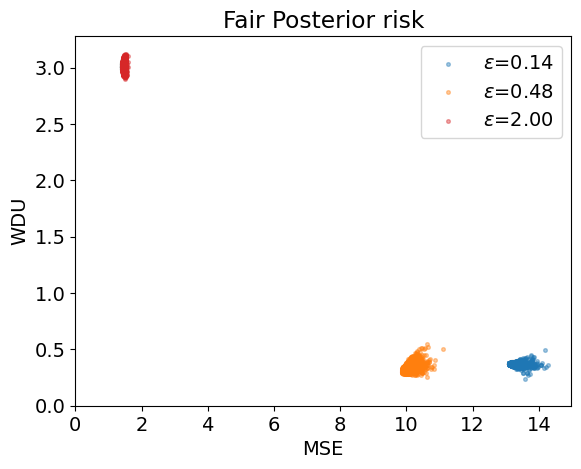

In [51]:
posterior_risk_2D_plot(fp_results_train, m1 = "MSE", m2="WDU", idx1=25, idx2=32, idx3=-10, savefig="regression_pp_risk_mse_wdu_train.pdf")
posterior_risk_2D_plot(fp_results_test, m1 = "MSE", m2="WDU", idx1=25, idx2=32, idx3=-10, savefig="regression_pp_risk_mse_wdu_test.pdf")

/var/folders/3v/7y8crp4n3fd1qpslr_sxl7c00000gn/T/ipykernel_9212/3201552591.py:11: RuntimeWarning: invalid value encountered in divide
  cumsum /= cumsum[-1]


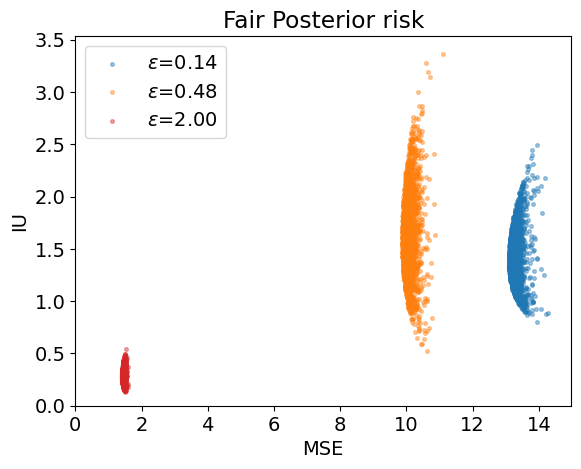

/var/folders/3v/7y8crp4n3fd1qpslr_sxl7c00000gn/T/ipykernel_9212/3201552591.py:11: RuntimeWarning: invalid value encountered in divide
  cumsum /= cumsum[-1]


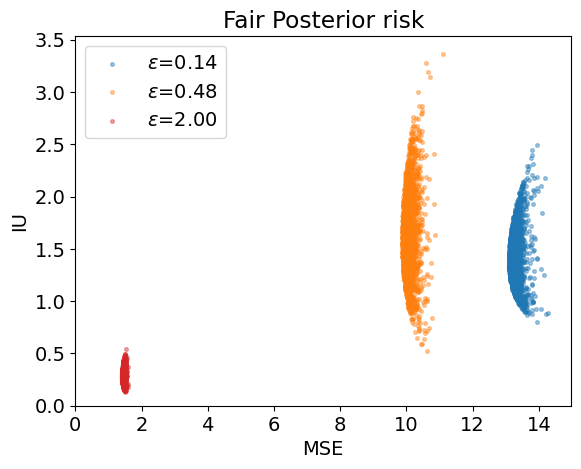

In [52]:
posterior_risk_2D_plot(pp_results_train, m1 = "MSE", m2="IU", idx1=25, idx2=32, idx3=-10,  savefig="regression_ppp_risk_mse_iu_train.pdf")
posterior_risk_2D_plot(pp_results_test, m1 = "MSE", m2="IU", idx1=25, idx2=32, idx3=-10,  savefig="regression_ppp_risk_mse_iu_test.pdf")

/var/folders/3v/7y8crp4n3fd1qpslr_sxl7c00000gn/T/ipykernel_9212/3201552591.py:11: RuntimeWarning: invalid value encountered in divide
  cumsum /= cumsum[-1]


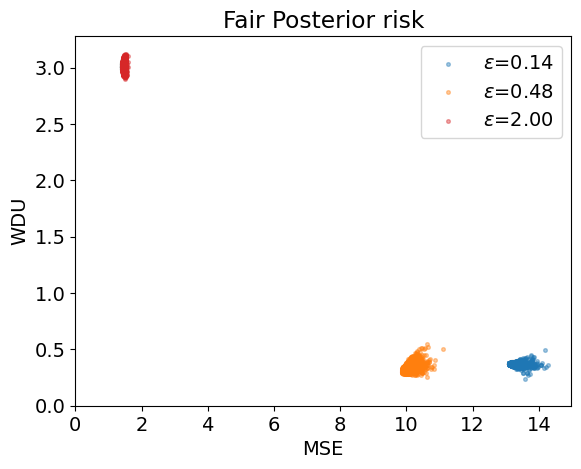

/var/folders/3v/7y8crp4n3fd1qpslr_sxl7c00000gn/T/ipykernel_9212/3201552591.py:11: RuntimeWarning: invalid value encountered in divide
  cumsum /= cumsum[-1]


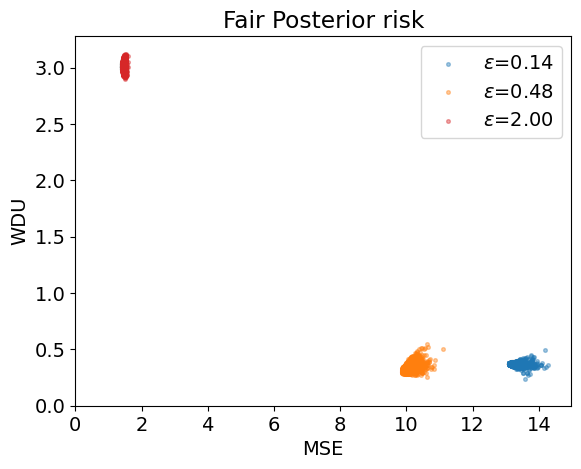

In [53]:
posterior_risk_2D_plot(fp_results_train, m1 = "MSE", m2="WDU", idx1=25, idx2=32, idx3=-10, savefig="regression_ppp_risk_mse_wdu_train.pdf")
posterior_risk_2D_plot(fp_results_test, m1 = "MSE", m2="WDU", idx1=25, idx2=32, idx3=-10, savefig="regression_ppp_risk_mse_wdu_test.pdf")